# Load and check dataset

In [ ]:
import pandas as pd

# Google Drive mount
from google.colab import drive
drive.mount('/content/drive')

# Google Drive dataset load
file_path = '/content/drive/MyDrive/Sleep_health_and_lifestyle_dataset.csv'

df = pd.read_csv(file_path)

# প্রথম ৫টি row
print(df.head())

# Dataset info
print(df.info())

# Statistical summary
print(df.describe())

# Missing values
print(df.isnull().sum())


Mounted at /content/drive
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1       

In [ ]:
# Install necessary libraries
!pip install pandas numpy scikit-learn matplotlib seaborn


# Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans



# Data Preprocessing and Clustering Pipeline

Dropped columns due to missing values: Index(['Sleep Disorder'], dtype='object')
After dropping missing rows: (373, 13)


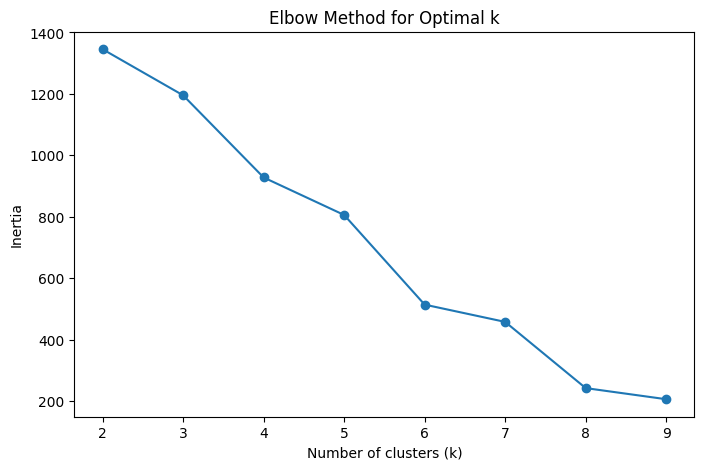

   Person ID  Sleep_Cluster
0          1              2
1          2              1
2          3              1
3          4              2
4          5              2
               Sleep Duration  Physical Activity Level  Stress Level  \
Sleep_Cluster                                                          
0                    7.603846                62.884615      4.273504   
1                    6.272650                53.991453      7.435897   
2                    6.640909                46.500000      6.409091   

               Heart Rate  Daily Steps  Sleep_Efficiency  
Sleep_Cluster                                             
0               67.769231  6973.504274          0.277918  
1               72.880342  7035.897436          0.120865  
2               81.318182  3977.272727          0.160312  


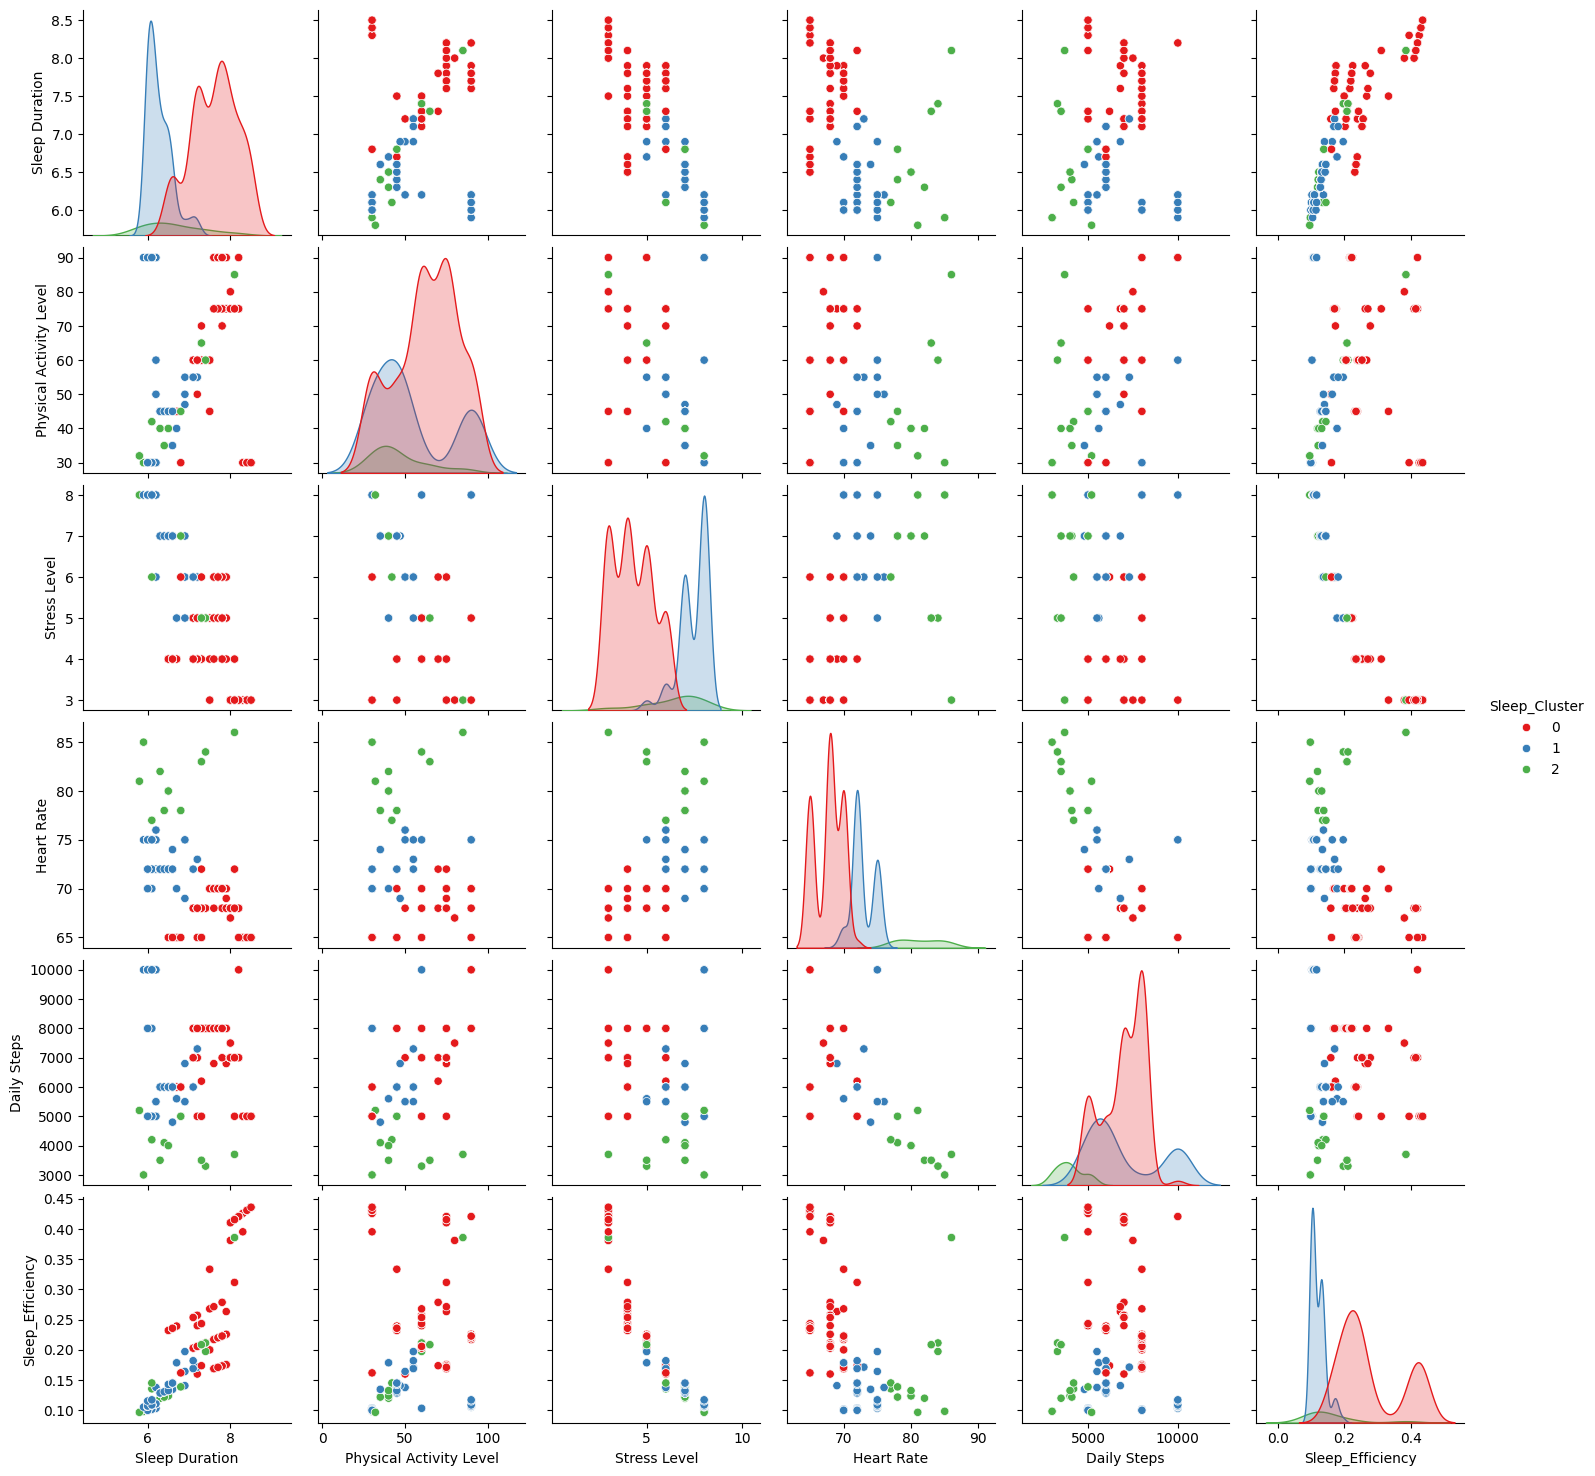

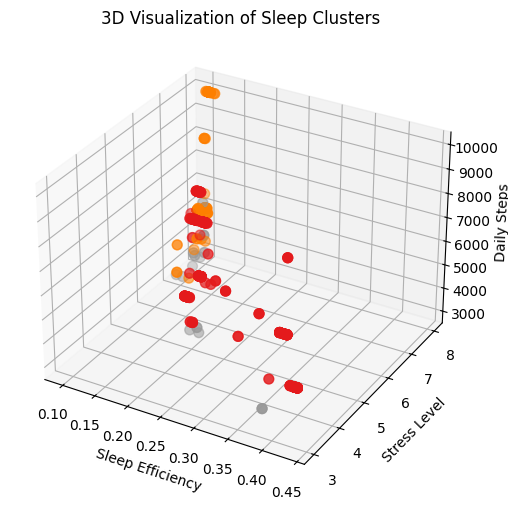

In [ ]:

#  Remove columns with excessive missing values

threshold = 0.3  # If more than 30% missing → drop column
cols_to_drop = df.columns[df.isnull().mean() > threshold]
df_cleaned = df.drop(columns=cols_to_drop)

print("Dropped columns due to missing values:", cols_to_drop)

#   Target Variable Handling (Binary Good/Poor Sleep)
df_cleaned['Quality_of_Sleep_Cat'] = df_cleaned['Quality of Sleep'].apply(
    lambda x: "Good" if x >= 7 else "Poor"
)

#   Remove remaining rows with missing values
df_cleaned = df_cleaned.dropna()
print("After dropping missing rows:", df_cleaned.shape)

#  Extra Feature: Sleep Efficiency Score
def age_factor(age):
    if age <= 35:
        return 7.5
    elif age <= 50:
        return 7.0
    else:
        return 6.5

df_cleaned['Age_Factor'] = df_cleaned['Age'].apply(age_factor)
df_cleaned['Sleep_Efficiency'] = df_cleaned['Sleep Duration'] / (df_cleaned['Stress Level'] * df_cleaned['Age_Factor'])

#   Prepare features for clustering
cluster_features = ['Sleep Duration', 'Physical Activity Level', 'Stress Level',
                    'Heart Rate', 'Daily Steps', 'Sleep_Efficiency']

# Scale features for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df_cleaned[cluster_features])

#   Elbow method to find optimal k
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

#   Fit K-Means
k = 3  # elbow method wise
kmeans = KMeans(n_clusters=k, random_state=42)
df_cleaned['Sleep_Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(df_cleaned[['Person ID', 'Sleep_Cluster']].head())

#  Analyze cluster characteristics
cluster_summary = df_cleaned.groupby('Sleep_Cluster')[cluster_features].mean()
print(cluster_summary)

#  Visualize clusters
sns.pairplot(df_cleaned, vars=cluster_features, hue='Sleep_Cluster', palette='Set1')
plt.show()

# 3D scatter for SES vs Stress vs Steps
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_cleaned['Sleep_Efficiency'], df_cleaned['Stress Level'], df_cleaned['Daily Steps'],
           c=df_cleaned['Sleep_Cluster'], cmap='Set1', s=50)
ax.set_xlabel('Sleep Efficiency')
ax.set_ylabel('Stress Level')
ax.set_zlabel('Daily Steps')
plt.title('3D Visualization of Sleep Clusters')
plt.show()


#   One-hot encode remaining categorical columns
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Daily Steps', 'Blood Pressure']
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# 8.Add cluster as a feature
X = df_cleaned.drop(['Quality of Sleep', 'Quality_of_Sleep_Cat'], axis=1)
y = df_cleaned['Quality_of_Sleep_Cat']

#   Standardize numeric columns
numeric_cols = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Sleep_Efficiency']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

#   Train-test split (STRATIFIED)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Model Definition, Training, and Evaluation

In [ ]:
# Define models
models = {
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier()
}

# Train and evaluate each model
results = {}
for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = model.score(X_test, y_test)
    classification_rep = classification_report(y_test, y_pred)
    confusion_mat = confusion_matrix(y_test, y_pred)

    results[model_name] = {
        'Accuracy': accuracy,
        'Classification Report': classification_rep,
        'Confusion Matrix': confusion_mat
    }

    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_rep)
    print("Confusion Matrix:\n", confusion_mat)
    print("-" * 50)


Model: Naive Bayes
Accuracy: 0.9821
Classification Report:
               precision    recall  f1-score   support

        Good       1.00      0.97      0.99        77
        Poor       0.95      1.00      0.97        35

    accuracy                           0.98       112
   macro avg       0.97      0.99      0.98       112
weighted avg       0.98      0.98      0.98       112

Confusion Matrix:
 [[75  2]
 [ 0 35]]
--------------------------------------------------
Model: SVM
Accuracy: 0.6875
Classification Report:
               precision    recall  f1-score   support

        Good       0.69      1.00      0.81        77
        Poor       0.00      0.00      0.00        35

    accuracy                           0.69       112
   macro avg       0.34      0.50      0.41       112
weighted avg       0.47      0.69      0.56       112

Confusion Matrix:
 [[77  0]
 [35  0]]
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model: K-Nearest Neighbors
Accuracy: 0.9018
Classification Report:
               precision    recall  f1-score   support

        Good       0.93      0.92      0.93        77
        Poor       0.83      0.86      0.85        35

    accuracy                           0.90       112
   macro avg       0.88      0.89      0.89       112
weighted avg       0.90      0.90      0.90       112

Confusion Matrix:
 [[71  6]
 [ 5 30]]
--------------------------------------------------
Model: Decision Tree
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00        77
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112

Confusion Matrix:
 [[77  0]
 [ 0 35]]
--------------------------------------------------
Model: Random Forest
Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: Logistic Regression
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00        77
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112

Confusion Matrix:
 [[77  0]
 [ 0 35]]
--------------------------------------------------
Model: Gradient Boosting
Accuracy: 0.9911
Classification Report:
               precision    recall  f1-score   support

        Good       0.99      1.00      0.99        77
        Poor       1.00      0.97      0.99        35

    accuracy                           0.99       112
   macro avg       0.99      0.99      0.99       112
weighted avg       0.99      0.99      0.99       112

Confusion Matrix:
 [[77  0]
 [ 1 34]]
--------------------------------------------------
Model: AdaBoost
Accuracy: 1.0000
C

# Visualizing the predictive performance of all trained models

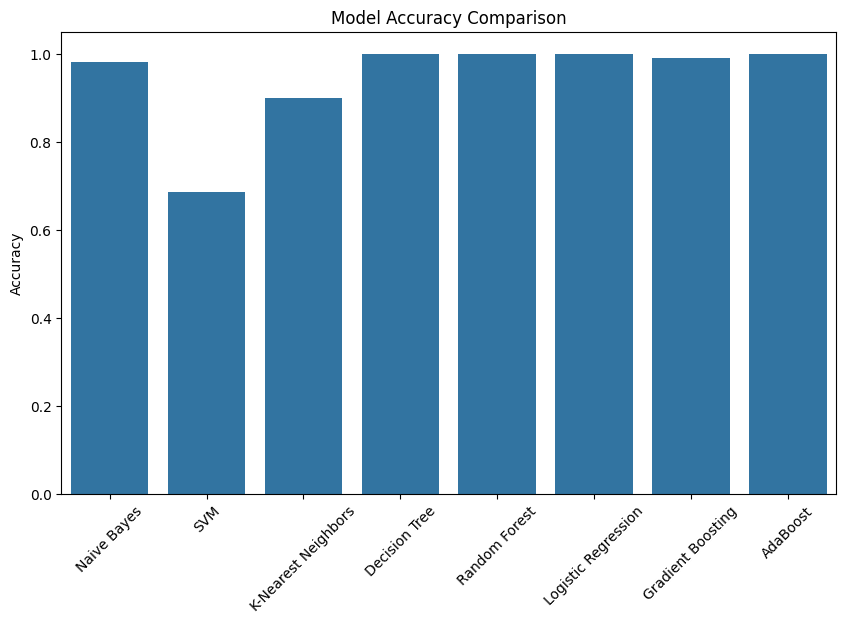

In [ ]:
#   Accuracy comparison plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=[results[m]['Accuracy'] for m in results])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

# Hyperparameter Tuning for Random Forest

In [ ]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
best_model = grid_rf.best_estimator_

#  Evaluate tuned Random Forest
y_pred_best = best_model.predict(X_test)
print("Tuned Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_best))

Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest Classification Report:

              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        77
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112



In [ ]:
!pip install shap


In [ ]:
import shap


# Convert all feature columns to numeric (float) type

In [ ]:

X_train_numeric = X_train.apply(lambda x: x.astype(float))
X_test_numeric = X_test.apply(lambda x: x.astype(float))

print(X_train_numeric.dtypes)  # should all be float64
print(X_test_numeric.dtypes)   # should all be float64


Person ID                  float64
Age                        float64
Sleep Duration             float64
Physical Activity Level    float64
Stress Level               float64
                            ...   
Blood Pressure_135/90      float64
Blood Pressure_139/91      float64
Blood Pressure_140/90      float64
Blood Pressure_140/95      float64
Blood Pressure_142/92      float64
Length: 66, dtype: object
Person ID                  float64
Age                        float64
Sleep Duration             float64
Physical Activity Level    float64
Stress Level               float64
                            ...   
Blood Pressure_135/90      float64
Blood Pressure_139/91      float64
Blood Pressure_140/90      float64
Blood Pressure_140/95      float64
Blood Pressure_142/92      float64
Length: 66, dtype: object


# SHAP (SHapley Additive exPlanations) Analysis for Model Interpretability

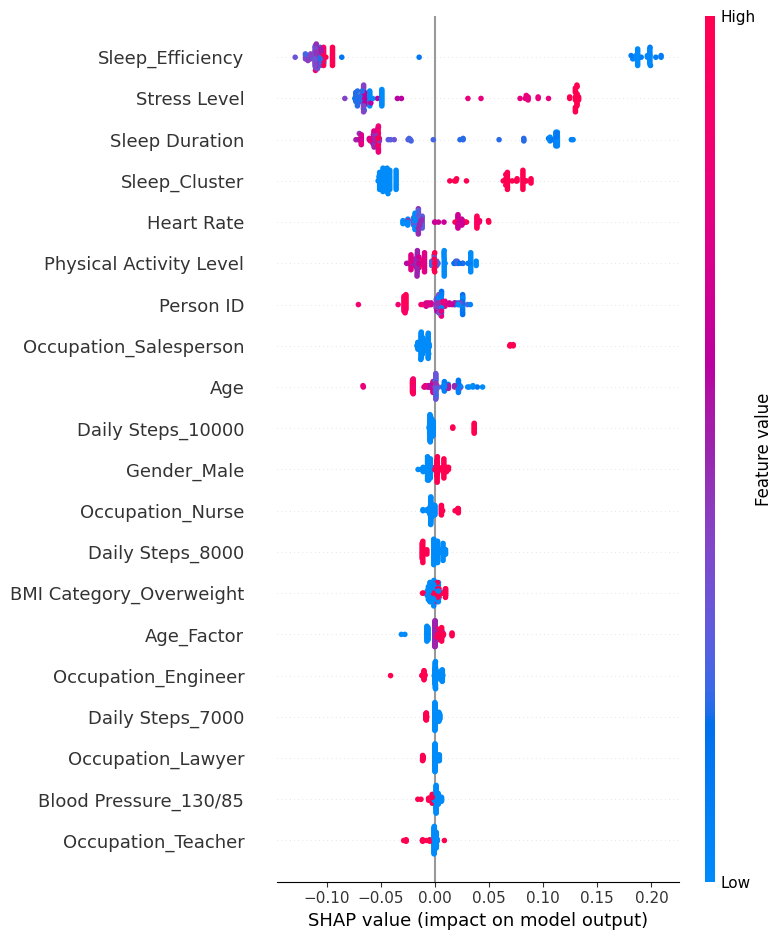

In [ ]:
import shap

# Make sure all features are float
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

#   SHAP Explainer
explainer = shap.Explainer(best_model, X_train_numeric)

# Compute SHAP values
shap_values = explainer(X_test_numeric)

#   Force plot for first sample, class 1
shap.initjs()
shap.plots.force(
    shap_values.base_values[0,1],       # base value for first sample, class 1
    shap_values.values[0,:,1],          # SHAP values for first sample, class 1
    X_test_numeric.iloc[0],             # feature values
    feature_names=X_test_numeric.columns
)
shap.summary_plot(
    shap_values.values[:,:,1],  # all samples, all features, class 1
    X_test_numeric
)


#  Section: Advanced Sleep Quality Analysis



## Cell 1: Advanced Feature Engineering

 original `df`
  working dataframe,
   encoded dataframe- conflict

In [ ]:
# Advanced Feature Engineering
import pandas as pd
import numpy as np

# Work from the original dataframe so previous one-hot encoding does not create conflict
df_adv = df.copy()

# Drop rows with missing values for a clean advanced pipeline
df_adv = df_adv.dropna().copy()

# Binary target: Good vs Poor sleep
df_adv["Quality_of_Sleep_Cat"] = df_adv["Quality of Sleep"].apply(
    lambda x: "Good" if x >= 7 else "Poor"
)

# Split Blood Pressure into Systolic and Diastolic values
if "Blood Pressure" in df_adv.columns:
    bp_split = df_adv["Blood Pressure"].astype(str).str.split("/", expand=True)
    df_adv["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df_adv["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")

# Convert BMI Category into an ordered numeric feature
bmi_map = {
    "Normal": 0,
    "Normal Weight": 0,
    "Overweight": 1,
    "Obese": 2
}
if "BMI Category" in df_adv.columns:
    df_adv["BMI_Level"] = df_adv["BMI Category"].map(bmi_map)

# New meaningful features
df_adv["Sleep_Stress_Ratio"] = df_adv["Sleep Duration"] / (df_adv["Stress Level"] + 1)
df_adv["Steps_per_Hour_Sleep"] = df_adv["Daily Steps"] / (df_adv["Sleep Duration"] + 1)
df_adv["Activity_Stress_Index"] = df_adv["Physical Activity Level"] / (df_adv["Stress Level"] + 1)
df_adv["HeartRate_Stress"] = df_adv["Heart Rate"] * df_adv["Stress Level"]

# Remove possible missing values created during conversion
df_adv = df_adv.dropna().copy()

print("Advanced dataframe shape:", df_adv.shape)
df_adv.head()


Advanced dataframe shape: (154, 21)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,...,Daily Steps,Sleep Disorder,Quality_of_Sleep_Cat,Systolic_BP,Diastolic_BP,BMI_Level,Sleep_Stress_Ratio,Steps_per_Hour_Sleep,Activity_Stress_Index,HeartRate_Stress
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,...,3000,Sleep Apnea,Poor,140,90,2,0.655556,434.782609,3.333333,680
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,...,3000,Sleep Apnea,Poor,140,90,2,0.655556,434.782609,3.333333,680
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,...,3000,Insomnia,Poor,140,90,2,0.655556,434.782609,3.333333,680
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,...,3500,Insomnia,Poor,140,90,2,0.787500,479.452055,5.000000,574
16,17,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,...,4000,Sleep Apnea,Poor,132,87,0,0.812500,533.333333,5.000000,560


## Cell 2: Extra Visualization

new feature sleep quality relationship  extra charts।

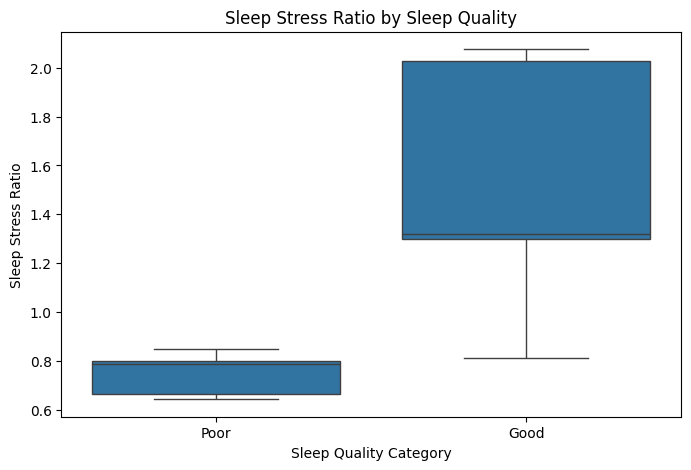

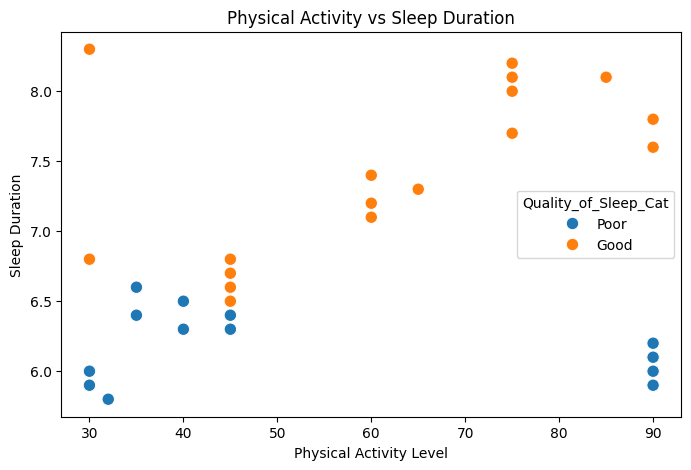

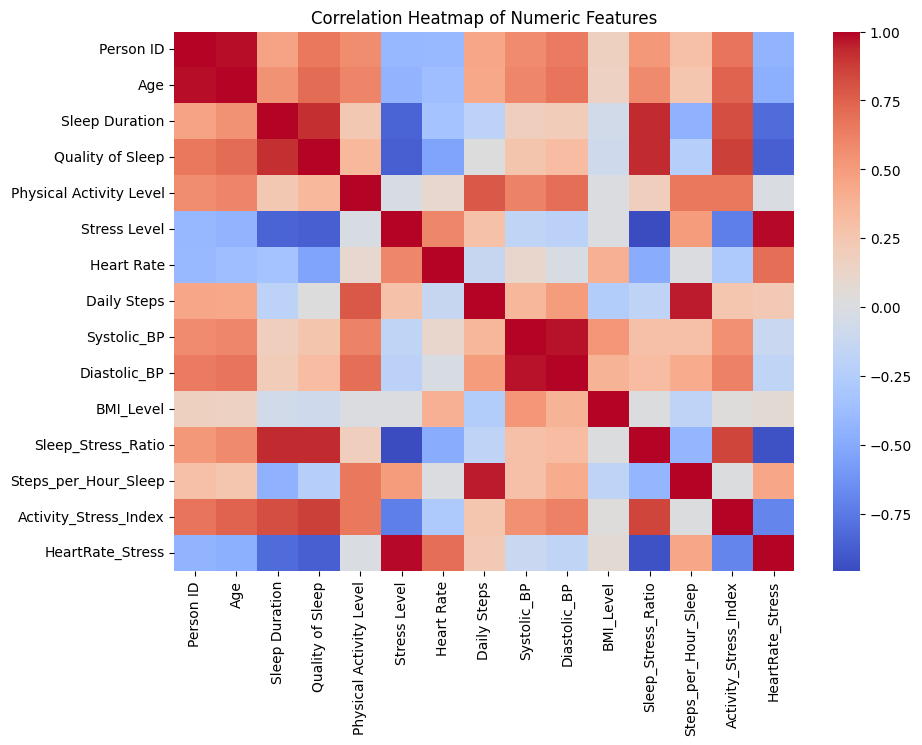

In [ ]:
# Extra Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_adv, x="Quality_of_Sleep_Cat", y="Sleep_Stress_Ratio")
plt.title("Sleep Stress Ratio by Sleep Quality")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Sleep Stress Ratio")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_adv,
    x="Physical Activity Level",
    y="Sleep Duration",
    hue="Quality_of_Sleep_Cat",
    s=80
)
plt.title("Physical Activity vs Sleep Duration")
plt.xlabel("Physical Activity Level")
plt.ylabel("Sleep Duration")
plt.show()

plt.figure(figsize=(10, 7))
numeric_for_corr = df_adv.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_for_corr.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


## Cell 3: Prepare Advanced ML Dataset

Categorical features one-hot encode  and numerical features scale

In [ ]:
# Prepare Advanced ML Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Columns not useful as direct features
drop_cols = ["Quality of Sleep", "Quality_of_Sleep_Cat"]

# Person ID is an identifier, not a real predictive feature
if "Person ID" in df_adv.columns:
    drop_cols.append("Person ID")

X_adv = df_adv.drop(columns=drop_cols)
y_adv = df_adv["Quality_of_Sleep_Cat"]

# One-hot encode categorical columns
X_adv = pd.get_dummies(X_adv, drop_first=True)

# Train-test split
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv,
    y_adv,
    test_size=0.30,
    random_state=42,
    stratify=y_adv
)

# Scale numeric data
scaler_adv = StandardScaler()
X_train_adv_scaled = scaler_adv.fit_transform(X_train_adv)
X_test_adv_scaled = scaler_adv.transform(X_test_adv)

print("Training shape:", X_train_adv.shape)
print("Testing shape:", X_test_adv.shape)


Training shape: (107, 40)
Testing shape: (47, 40)


## Cell 4: Advanced Model Comparison

Extra Trees, Random Forest, Gradient Boosting, HistGradientBoosting and Voting Classifier compare

In [ ]:
# Advanced Model Comparison
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

advanced_models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "SVM RBF": SVC(kernel="rbf", probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

advanced_results = {}

for name, model in advanced_models.items():
    model.fit(X_train_adv_scaled, y_train_adv)
    y_pred_adv = model.predict(X_test_adv_scaled)
    acc = accuracy_score(y_test_adv, y_pred_adv)

    advanced_results[name] = acc

    print("=" * 60)
    print(name)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test_adv, y_pred_adv))

# Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(random_state=42, n_estimators=200)),
        ("et", ExtraTreesClassifier(random_state=42, n_estimators=200)),
        ("lr", LogisticRegression(max_iter=1000, random_state=42))
    ],
    voting="soft"
)

voting_model.fit(X_train_adv_scaled, y_train_adv)
voting_pred = voting_model.predict(X_test_adv_scaled)
voting_acc = accuracy_score(y_test_adv, voting_pred)

advanced_results["Voting Classifier"] = voting_acc

print("=" * 60)
print("Voting Classifier")
print("Accuracy:", round(voting_acc, 4))
print(classification_report(y_test_adv, voting_pred))


Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        24
        Poor       1.00      1.00      1.00        23

    accuracy                           1.00        47
   macro avg       1.00      1.00      1.00        47
weighted avg       1.00      1.00      1.00        47

Extra Trees
Accuracy: 1.0
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        24
        Poor       1.00      1.00      1.00        23

    accuracy                           1.00        47
   macro avg       1.00      1.00      1.00        47
weighted avg       1.00      1.00      1.00        47

Gradient Boosting
Accuracy: 1.0
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        24
        Poor       1.00      1.00      1.00        23

    accuracy                           1.00        47
   macro avg       1.00      1.00      1.0

## Cell 5: Advanced Model Accuracy Chart

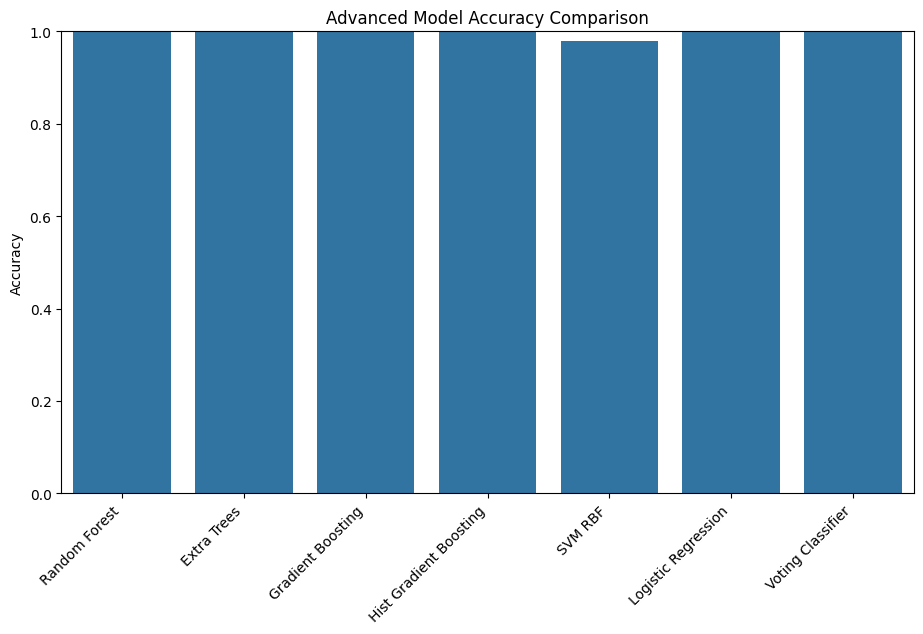

In [ ]:
# Advanced Model Accuracy Chart
plt.figure(figsize=(11, 6))
sns.barplot(x=list(advanced_results.keys()), y=list(advanced_results.values()))
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Advanced Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()


## Cell 6: Cross-Validation

train-test split- dependency skip cross-validation
model stability check

Random Forest: Mean CV Accuracy = 0.9742, Std = 0.0241
Extra Trees: Mean CV Accuracy = 0.9355, Std = 0.1136
Gradient Boosting: Mean CV Accuracy = 0.8839, Std = 0.1750
Hist Gradient Boosting: Mean CV Accuracy = 0.9742, Std = 0.0241
SVM RBF: Mean CV Accuracy = 0.6710, Std = 0.2710
Logistic Regression: Mean CV Accuracy = 1.0000, Std = 0.0000


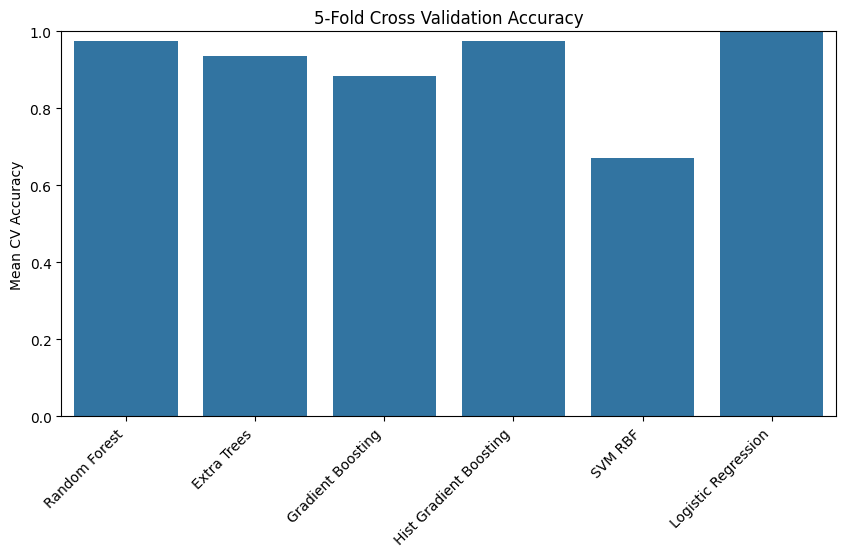

In [ ]:
# Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = {}

for name, model in advanced_models.items():
    scores = cross_val_score(model, X_adv, y_adv, cv=5, scoring="accuracy")
    cv_scores[name] = scores.mean()
    print(f"{name}: Mean CV Accuracy = {scores.mean():.4f}, Std = {scores.std():.4f}")

plt.figure(figsize=(10, 5))
sns.barplot(x=list(cv_scores.keys()), y=list(cv_scores.values()))
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean CV Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.ylim(0, 1)
plt.show()


## Cell 7: Feature Importance

Random Forest

,Feature,Importance
9,Sleep_Stress_Ratio,0.174097
12,HeartRate_Stress,0.144392
3,Stress Level,0.143706
1,Sleep Duration,0.114917
4,Heart Rate,0.087011
0,Age,0.067963
10,Steps_per_Hour_Sleep,0.049973
11,Activity_Stress_Index,0.043278
5,Daily Steps,0.032616
13,Gender_Male,0.026554


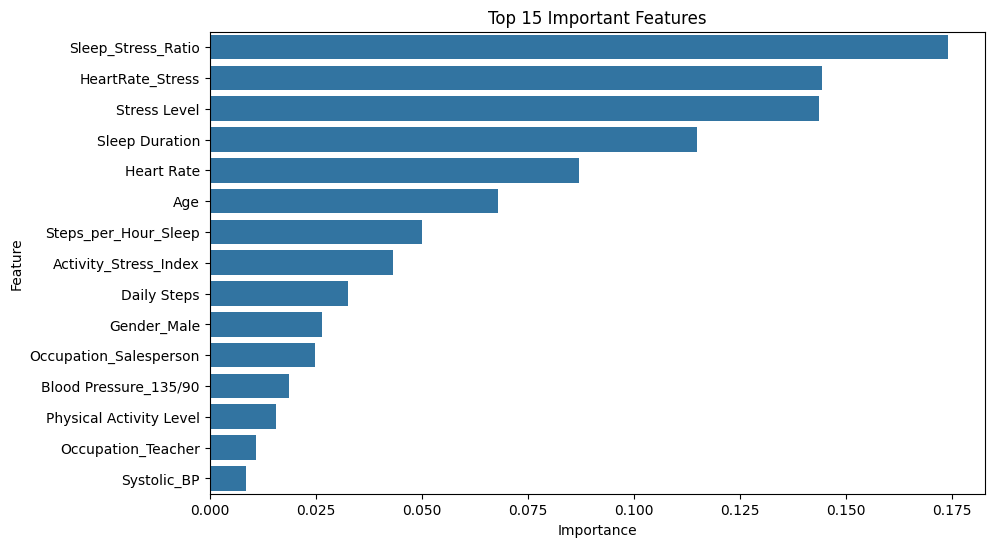

In [ ]:
# Feature Importance
best_rf_adv = RandomForestClassifier(random_state=42, n_estimators=300)
best_rf_adv.fit(X_train_adv, y_train_adv)

feature_importance = pd.DataFrame({
    "Feature": X_train_adv.columns,
    "Importance": best_rf_adv.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Cell 8: Confusion Matrix for Best Model

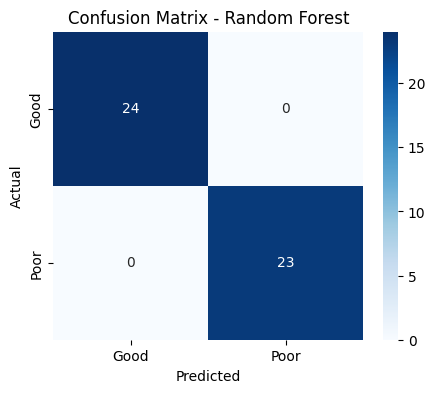

Best advanced model: Random Forest
Best accuracy: 1.0


In [ ]:
# Confusion Matrix for Best Model
best_model_name = max(advanced_results, key=advanced_results.get)

if best_model_name == "Voting Classifier":
    final_model_adv = voting_model
else:
    final_model_adv = advanced_models[best_model_name]
    final_model_adv.fit(X_train_adv_scaled, y_train_adv)

final_pred_adv = final_model_adv.predict(X_test_adv_scaled)

cm = confusion_matrix(y_test_adv, final_pred_adv)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=final_model_adv.classes_,
            yticklabels=final_model_adv.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Best advanced model:", best_model_name)
print("Best accuracy:", round(advanced_results[best_model_name], 4))


## Cell 9: Sleep Improvement Recommendation System



In [ ]:
# Sleep Improvement Recommendation System
def sleep_recommendation(row):
    tips = []

    if row["Sleep Duration"] < 7:
        tips.append("Try to sleep at least 7 hours per night.")

    if row["Stress Level"] >= 7:
        tips.append("Stress level is high. Try meditation, breathing exercise, or screen-free time before sleep.")

    if row["Physical Activity Level"] < 40:
        tips.append("Increase daily physical activity gradually.")

    if row["Daily Steps"] < 6000:
        tips.append("Try to walk more; aim for at least 6000-8000 steps per day.")

    if row["Heart Rate"] > 80:
        tips.append("Heart rate is relatively high. Consider relaxation and consult a professional if needed.")

    if len(tips) == 0:
        tips.append("Your sleep-related habits look good. Maintain your routine.")

    return " ".join(tips)

df_adv["Recommendation"] = df_adv.apply(sleep_recommendation, axis=1)

df_adv[["Sleep Duration", "Stress Level", "Physical Activity Level", "Daily Steps", "Heart Rate", "Quality_of_Sleep_Cat", "Recommendation"]].head(10)


,Sleep Duration,Stress Level,Physical Activity Level,Daily Steps,Heart Rate,Quality_of_Sleep_Cat,Recommendation
3,5.9,8,30,3000,85,Poor,Try to sleep at least 7 hours per night. Stres...
4,5.9,8,30,3000,85,Poor,Try to sleep at least 7 hours per night. Stres...
5,5.9,8,30,3000,85,Poor,Try to sleep at least 7 hours per night. Stres...
6,6.3,7,40,3500,82,Poor,Try to sleep at least 7 hours per night. Stres...
16,6.5,7,40,4000,80,Poor,Try to sleep at least 7 hours per night. Stres...
17,6.0,8,30,8000,70,Poor,Try to sleep at least 7 hours per night. Stres...
18,6.5,7,40,4000,80,Poor,Try to sleep at least 7 hours per night. Stres...
30,6.4,7,35,4100,78,Poor,Try to sleep at least 7 hours per night. Stres...
31,6.4,7,35,4100,78,Poor,Try to sleep at least 7 hours per night. Stres...
49,7.7,6,75,8000,70,Good,Your sleep-related habits look good. Maintain ...
